# ML and Linear Regression

This notebook is a simple guide to Machine Learning and Linear Regression.

## 🧠 1. Introduction to Machine Learning

Machine Learning (ML) is when computers learn from data instead of being told exactly what to do by a programmer.

For a full introduction, see the [Google Machine Learning Crash Course](https://developers.google.com/machine-learning/intro-to-ml/what-is-ml).

### Types of ML Systems

Machine Learning systems can be classified into main types:

1.  **Supervised Learning**: Learning with a teacher. We give the computer questions and the correct answers.
    *   *Example*: Predicting house prices based on size.
2.  **Unsupervised Learning**: Learning on its own. The computer finds patterns in data by itself.
    *   *Example*: Grouping similar customers together.
3.  **Reinforcement Learning**: Learning by trial and error. The computer learns by playing and getting points or penalties.
    *   *Example*: A computer learning to play a video game.
4.  **Generative AI**: Models that can create new content (text, images, music) after learning from existing content.
    *   *Example*: Chatbots generating responses or image generators creating art.

## 🎯 2. Supervised Learning

In Supervised Learning, we teach the computer by showing it examples with answers. We give it inputs (like house size) and the correct outputs (like house price). The goal is for the computer to learn the connection so it can guess the answer for new examples.

There are two main types:
- **Regression**: Predicting a number (e.g., a price or temperature).
- **Classification**: Predicting a category (e.g., spam or not spam).

---

### Core Concepts of Supervised Learning

Supervised machine learning is based on the following core concepts:

*   **Data**: The examples we use to teach the model. It consists of **Features** (what we know, e.g., trip distance) and **Labels** (what we want to predict, e.g., taxi fare).
*   **Model**: The mathematical formula or rule that connects features to labels (e.g., $y = wx + b$).
*   **Training**: The process of teaching the model by showing it data and letting it adjust its internal settings to make better guesses.
*   **Evaluating**: **Measuring how good the model is.** We test it on a separate set of data (that the model hasn't seen during training) to get a score of its accuracy. This tells us if it's ready to be used.
*   **Inference**: **Using the trained model to make predictions.** Once we are happy with the evaluation, we use the model to calculate predictions for new, real-world data.

## 🎯 3. Linear Regression

Linear Regression is a Supervised Learning method used to predict a number (Regression). It tries to draw the best straight line through the data points.

### The Math Formula: `y = wx + b`

*   **y**: The answer we want to guess (e.g., Taxi Fare).
*   **x**: The information we know (e.g., Trip Distance).
*   **w** (Weight): The slope. How much the fare increases per mile.
*   **b** (Bias): The starting point. The base fee just for getting in the taxi.

### 🚕 The Taxi Fare Example
Imagine you are a taxi driver and want to predict how much to charge for a trip. You know that longer trips cost more, and there is also a base fee just for starting the trip.

**How Linear Regression helps:**
It looks at your past trips and finds the best values for **w** (price per mile) and **b** (base fee). Once found, you can use the formula $y = wx + b$ to predict a fair fare for any new trip distance.

## 📉 4. Measuring Success: The Loss Function

In Machine Learning, **Loss** is the difference between the **Actual** value and the **Predicted** value.
*   If the model predicts perfectly, the loss is $0$.
*   **The goal of training is to minimize this loss** to make the model as accurate as possible.

### Types of Loss

Here are the common types of loss used in Linear Regression.

| Loss Type | Definition | Formula (English) | Formula (Symbol) |
| :--- | :--- | :--- | :--- |
| **L1 Loss** | Absolute difference for a single example. | `Absolute value of (Actual - Predicted)` | $\|y - y'\|$ |
| **MAE** | Average of L1 losses. | `Average of all L1 losses` | $\frac{1}{N} \sum \|y - y'\|$ |
| **L2 Loss** | Squared difference for a single example. | `(Actual - Predicted) squared` | $(y - y')^2$ |
| **MSE** | Average of L2 losses. | `Average of all L2 losses` | $\frac{1}{N} \sum (y - y')^2$ |
| **RMSE** | Square root of MSE. | `Square root of MSE` | $\sqrt{MSE}$ |

### ⚖️ Comparing MSE vs. MAE with an Example

Imagine we have two trips where the model made errors:
- Trip 1: Model was off by $2$ dollars.
- Trip 2: Model was off by $10$ dollars (an Outlier).

**MAE (Mean Absolute Error)** treats errors linearly:
- Loss for Trip 1 = $2$
- Loss for Trip 2 = $10$
- Total Loss = $12$

**MSE (Mean Squared Error)** squares the errors:
- Loss for Trip 1 = $2^2 = 4$
- Loss for Trip 2 = $10^2 = 100$
- Total Loss = $104$

**Key Difference**: MSE punishes large errors (outliers) much more heavily than MAE. Use MSE if you want to avoid large mistakes at all costs. Use MAE if you want to be more robust to outliers.

### 🧮 NumPy for Loss Calculation

Before we use TensorFlow to automate everything, let's use **NumPy** to calculate these loss functions manually. NumPy allows us to perform mathematical operations on entire arrays of data at once (vectorization), which is much faster and cleaner than using loops.

In the code cell below, we simulate 3 taxi trips and calculate the different types of loss we just discussed using NumPy functions like `np.abs`, `np.square`, and `np.mean`.

In [ ]:
#@title Install required libraries

!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

print('\n\nAll requirements successfully installed.')

In [5]:
import numpy as np

# Let's say we have 3 taxi trips
actual_fares = np.array([12.00, 25.00, 40.00])
predicted_fares = np.array([13.50, 21.00, 45.00])  # Our model's guesses

# 1. L1 Loss (Absolute Error for each trip)
l1_losses = np.abs(actual_fares - predicted_fares)

# 2. MAE (Mean Absolute Error)
mae = np.mean(l1_losses)

# 3. L2 Loss (Squared Error for each trip)
l2_losses = np.square(actual_fares - predicted_fares)

# 4. MSE (Mean Squared Error)
mse = np.mean(l2_losses)

# 5. RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

print(f"Actual Fares:    [{', '.join(map(lambda x: f'{x:.2f}', actual_fares))}]")
print(f"Predicted Fares: [{', '.join(map(lambda x: f'{x:.2f}', predicted_fares))}]")
print("-" * 30)
print(f"L1 Losses (per trip):  [{', '.join(map(lambda x: f'{x:.2f}', l1_losses))}]")
print(f"MAE (Average L1):      ${mae:.2f}")
print(f"L2 Losses (per trip):  [{', '.join(map(lambda x: f'{x:.2f}', l2_losses))}]")
print(f"MSE (Average L2):      {mse:.2f}")
print(f"RMSE (Standard Error): ${rmse:.2f}")

Actual Fares:    [12.00, 25.00, 40.00]
Predicted Fares: [13.50, 21.00, 45.00]
------------------------------
L1 Losses (per trip):  [1.50, 4.00, 5.00]
MAE (Average L1):      $3.50
L2 Losses (per trip):  [2.25, 16.00, 25.00]
MSE (Average L2):      14.42
RMSE (Standard Error): $3.80


## 🔄 5. Optimization: Gradient Descent

### Why do we need it?
We have the formula $y = wx + b$, but we don't know the best values for $w$ and $b$. We could try guessing randomly, but that would be extremely slow and inefficient. We need an automated, smart way to find the values that give us the lowest possible loss.

### What it does:
**Gradient Descent** is that smart way. It starts with random guesses and iteratively takes steps in the direction that reduces the loss, like walking down a foggy mountain to find the bottom.

---

### Deriving the Gradient (The "Fix")
To know which way is "down," we take the derivative of the MSE formula with respect to the weight ($w$):
1. Start with $Loss = (y - (wx + b))^2$
2. Use the **Chain Rule**: The derivative of $(\text{something})^2$ is $2 \times (\text{something}) \times (\text{derivative of inner part})$.
3. The derivative of $(y - wx - b)$ with respect to $w$ is $-x$.
4. **The Derived Gradient**: $Gradient = -2x(y - y_{predicted}) = -2x(Error)$.

### Why do we often remove the `2`?
In many implementations, you might see the gradient written without the `2` constant:
$$Gradient = -x(Actual - Predicted)$$

We can safely ignore the `2` because it is just a constant scaling factor. Its magnitude can be absorbed by the **Learning Rate**. What matters most is the **direction** of the gradient (positive or negative), which tells us whether to increase or decrease the weight.

### The Update Rule
**$$w_{new} = w_{old} - (Learning\_Rate \times Gradient)$$**

Let's see this calculation in code!

### ⛰️ Convergence and Convex Functions

For more detail, see the [ML Crash Course: Convergence and Convex Functions](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent#convergence_and_convex_functions).

When we train a model, we are looking for the point where the loss is as low as possible. Two concepts make this possible for Linear Regression:

#### 1. Convex Functions (The "Bowl")
In Linear Regression, the Mean Squared Error (MSE) loss function is **convex**. This means it is shaped like a bowl.
*   **One Bottom**: A convex function has only one minimum point (the **Global Minimum**).
*   **No Traps**: There are no "dips" or local pits where the model could get stuck. No matter where you start on the bowl, going "downhill" will always lead you to the same bottom.

#### 2. Convergence
**Convergence** is the state where the model has finished training.
*   As the model gets closer to the bottom of the bowl, the gradient (the slope) becomes flatter and flatter.
*   Eventually, the updates to the weights become so tiny that the loss stops changing.
*   At this point, we say the model has **converged** on the optimal solution.

In [6]:
# Manual Gradient Descent: Reaching Convergence
weight = 10.0  # Initial guess
learning_rate = 0.05
actual_fare = 25.0
miles = 2.0

# Convergence settings
threshold = 0.001  # Stop when weight changes by less than this
max_iterations = 100

print(f"Target Fare: ${actual_fare:.2f} | Starting Weight: {weight}\n")
print(f"{'Iter':<5} | {'Weight':<10} | {'Prediction':<12} | {'Error':<10}")
print("-" * 50)

for i in range(max_iterations):
    # 1. Prediction and Error
    prediction = weight * miles
    error = prediction - actual_fare

    # 2. Calculate Gradient
    gradient = miles * error

    # 3. Update Weight
    adjustment = learning_rate * gradient
    new_weight = weight - adjustment

    # Print progress every few steps or at the end
    if i < 5 or abs(adjustment) < threshold:
        print(f"{i+1:<5} | {weight:<10.4f} | ${prediction:<11.2f} | {error:<10.2f}")

    # 4. Check for Convergence
    if abs(adjustment) < threshold:
        print("-" * 50)
        print(f"✅ Converged at iteration {i+1}!")
        print(f"Final Learned Weight: {weight:.4f}")
        print(f"Final Prediction:     ${prediction:.2f}")
        break

    weight = new_weight

Target Fare: $25.00 | Starting Weight: 10.0

Iter  | Weight     | Prediction   | Error     
--------------------------------------------------
1     | 10.0000    | $20.00       | -5.00     
2     | 10.5000    | $21.00       | -4.00     
3     | 10.9000    | $21.80       | -3.20     
4     | 11.2200    | $22.44       | -2.56     
5     | 11.4760    | $22.95       | -2.05     
29    | 12.4952    | $24.99       | -0.01     
--------------------------------------------------
✅ Converged at iteration 29!
Final Learned Weight: 12.4952
Final Prediction:     $24.99


## ⚙️ 6. Hyperparameters: The Control Knobs

Hyperparameters are settings we choose manually to control the learning process.

For more details, see the [Google Machine Learning Crash Course: Hyperparameters](https://developers.google.com/machine-learning/crash-course/linear-regression/hyperparameters).

- 🎓 **Learning Rate (Step Size)**: How big a step the model takes when updating its guesses.
- 🔄 **Batch Size**: How many examples the model looks at *before* updating its understanding.
- 🔄 **Epochs**: How many times the model goes through the *entire* dataset.

### 📚 The Book Analogy (Epochs vs. Batches)
Imagine you have a book with **100 pages** (your full dataset) that you want to learn:
*   **Batch Size = 10**: You read 10 pages, stop to think and update your understanding, then read the next 10 pages. You repeat this until you finish the book.
*   **Epoch = 1**: One full pass through all 100 pages. If you read the whole book once, that's 1 epoch. If you read it 5 times to understand it better, that's 5 epochs.

### 🤔 Why do we need more than 1 Epoch?
You might wonder, why can't we just read the book once (1 Epoch) and be done?
In Machine Learning, the model makes very small adjustments to its weights in each step to avoid overshooting the best solution. Seeing all data points just once is usually not enough for the model to learn the complex relationships. It needs to review the data multiple times (multiple epochs) to gradually minimize the loss and find the best fit.

In [7]:
# Simulating Epochs and Batches in code
total_pages = 100  # Total data points

# Hyperparameters
epochs = 3  # We will read the whole book 3 times
batch_size = 20  # We read 20 pages before updating our mind

print(
    f"Starting training with {epochs} Epochs and Batch Size of {batch_size}.\n"
)

for epoch in range(1, epochs + 1):
    print(f"--- Starting Epoch {epoch} ---")

    # Loop through the data in batches
    for batch_start in range(0, total_pages, batch_size):
        batch_end = batch_start + batch_size
        print(f"Reading pages {batch_start} to {batch_end}...")

        # Simulation of weight update
        print("  [Updating model's understanding based on this batch]")

    print(f"Finished full pass (Epoch {epoch}) through the data.\n")

print("Training complete!")

Starting training with 3 Epochs and Batch Size of 20.

--- Starting Epoch 1 ---
Reading pages 0 to 20...
  [Updating model's understanding based on this batch]
Reading pages 20 to 40...
  [Updating model's understanding based on this batch]
Reading pages 40 to 60...
  [Updating model's understanding based on this batch]
Reading pages 60 to 80...
  [Updating model's understanding based on this batch]
Reading pages 80 to 100...
  [Updating model's understanding based on this batch]
Finished full pass (Epoch 1) through the data.

--- Starting Epoch 2 ---
Reading pages 0 to 20...
  [Updating model's understanding based on this batch]
Reading pages 20 to 40...
  [Updating model's understanding based on this batch]
Reading pages 40 to 60...
  [Updating model's understanding based on this batch]
Reading pages 60 to 80...
  [Updating model's understanding based on this batch]
Reading pages 80 to 100...
  [Updating model's understanding based on this batch]
Finished full pass (Epoch 2) through 

## 🚀 7. Scaling Up: Multiple Features

Real-world problems are rarely solved by just one feature. For our taxi example, **Distance** (Miles) is important, but **Time** (Minutes) also matters because drivers charge for time spent in traffic.

### Multiple Linear Regression Formula
We simply add more weights for each new feature:
**$$y = w_1x_1 + w_2x_2 + b$$**

- **$w_1$**: Weight for Miles (Price per mile).
- **$x_1$**: Trip Miles.
- **$w_2$**: Weight for Time (Price per minute).
- **$x_2$**: Trip Minutes.

**The Improvement**: By adding more information, our model can make much more accurate predictions. For example, a 1-mile trip in heavy traffic will now correctly cost more than a 1-mile trip on an empty road.

---
## 🛠️ 8. Real-World Implementation with TensorFlow

Now we will apply these concepts to thousands of Chicago Taxi trips.

### 🧱 What are TensorFlow and Keras?

So far, we have calculated loss and updated weights manually using NumPy. This was great for understanding the math! However, for real-world problems, we use specialized libraries to automate this.

While often used together, **TensorFlow** and **Keras** serve different purposes:

1.  **TensorFlow**: This is the **low-level engine**. It handles all the complex heavy math, tracks gradients automatically, and communicates with hardware like GPUs to make training fast.
    *   *Analogy*: It is the powerful engine under the hood of a car.
2.  **Keras**: This is the **high-level user interface** (API). It provides simple, easy-to-use building blocks (like layers and optimizers) so you don't have to write complex low-level code directly.
    *   *Analogy*: It is the steering wheel, pedals, and dashboard that make the car easy to drive.

In short, you use Keras to design your model simply, and Keras tells TensorFlow to do all the hard math in the background.

### 📊 What is a DataFrame?

In the code below, we use **Pandas**, a popular data manipulation library in Python. Pandas uses a central object called a **DataFrame** to store and manipulate data.

A **DataFrame** is a 2-dimensional labeled data structure, similar to a spreadsheet or a SQL table. It has rows and named columns, making it easy to select, filter, and analyze data.

In [8]:
import pandas as pd

# Load Data
DATA_URL = 'https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv'
df = pd.read_csv(DATA_URL)
training_df = df.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE')].dropna()

# Feature Engineering: Convert seconds to minutes
training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS'] / 60.0

print(f"Loaded {len(training_df):,} trips.")

Loaded 31,694 trips.


In [9]:
print('--- Raw Data (df) ---')
display(df.head())

print('\n--- Prepared Training Data (training_df) ---')
display(training_df.head())

--- Raw Data (df) ---


,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab



--- Prepared Training Data (training_df) ---


,TRIP_MILES,TRIP_SECONDS,FARE,TRIP_MINUTES
0,2.57,2341,31.99,39.016667
1,1.18,1074,9.75,17.900000
2,1.29,1173,10.25,19.550000
3,3.70,3360,23.75,56.000000
4,1.15,1044,10.00,17.400000


### Defining our Automated Solver

**Complex Functions Explained:**
- `tf.keras.layers.Dense(units=1)`: Creates our mathematical line. If we give it 1 feature, it's $y=wx+b$. If we give it 2 features, it automatically becomes $y=w_1x_1+w_2x_2+b$.
- `optimizer=RMSprop`: Our Gradient Descent Engine. For multiple features, it calculates the gradient for **every weight** ($w_1, w_2$) and updates them simultaneously.

### 🏗️ Building vs. Training a Model

In the code below, we separate the process into two distinct functions: `build_model` and `train_model`.

**Why are they separate?**

1.  **`build_model` (The Blueprint)**: This function defines the **structure** of the model (how many layers, what kind of layers) and how it will measure its success and improve (Loss function and Optimizer). We do this once to create the model.
2.  **`train_model` (The Learning Process)**: This function takes the built model and feeds it the actual **data** to let it learn.

**Why separate them?**
Separation of concerns makes the code cleaner and more flexible. It allows us to create a model structure once, and then train it multiple times with different data, or experiment with different training hyperparameters (like epochs and batch size) without having to redefine the model's structure every time.

In [10]:
import tensorflow as tf

def build_model(learning_rate, feature_count):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(units=1, input_shape=(feature_count,))
    ])
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

def train_model(model, df, feature_list, label, epochs, batch_size):
    history = model.fit(x=df[feature_list], y=df[label], batch_size=batch_size, epochs=epochs, verbose=0)
    return history

## 🧪 9. Train a model with one or more features comparison

Let's compare the **Single Feature** model (Miles only) against the **Multiple Feature** model (Miles + Minutes) to see the improvement.

### Train Model

In [11]:
learning_rate = 0.01
epochs = 30
batch_size = 50

# 1. Train Model with 1 Feature (Miles)
model_1 = build_model(learning_rate, feature_count=1)
history_1 = train_model(model_1, training_df, ['TRIP_MILES'], 'FARE', epochs, batch_size)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Experiment with hyperparameters

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


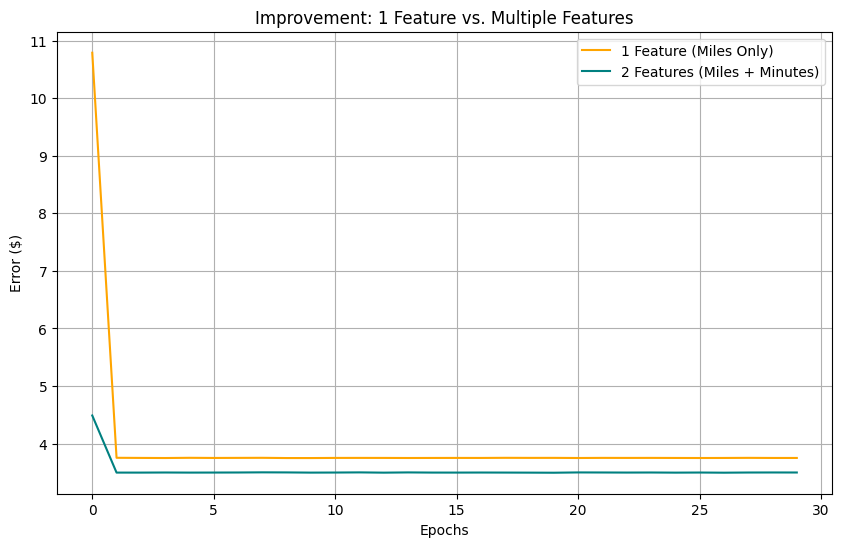

Final Error (Miles Only):    $3.75
Final Error (Miles + Mins):  $3.50
Total Accuracy Improvement:  6.7%


In [12]:
import matplotlib.pyplot as plt

# 2. Train Model with 2 Features (Miles + Minutes)
model_2 = build_model(learning_rate, feature_count=2)
history_2 = train_model(model_2, training_df, ['TRIP_MILES', 'TRIP_MINUTES'], 'FARE', epochs, batch_size)

plt.figure(figsize=(10, 6))
plt.plot(history_1.history['root_mean_squared_error'], label='1 Feature (Miles Only)', color='orange')
plt.plot(history_2.history['root_mean_squared_error'], label='2 Features (Miles + Minutes)', color='teal')
plt.title('Improvement: 1 Feature vs. Multiple Features')
plt.xlabel('Epochs')
plt.ylabel('Error ($)')
plt.legend()
plt.grid(True)
plt.show()

final_err_1 = history_1.history['root_mean_squared_error'][-1]
final_err_2 = history_2.history['root_mean_squared_error'][-1]
improvement = ((final_err_1 - final_err_2) / final_err_1) * 100

print(f"Final Error (Miles Only):    ${final_err_1:.2f}")
print(f"Final Error (Miles + Mins):  ${final_err_2:.2f}")
print(f"Total Accuracy Improvement:  {improvement:.1f}%")

### Validate Model
Let's see our best model (Multiple Features) in action!

### 📊 Evaluation

Evaluating the model means measuring its performance on data it hasn't seen during training (or a representative sample) to get a score of its accuracy.

Evaluation RMSE: $4.41
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


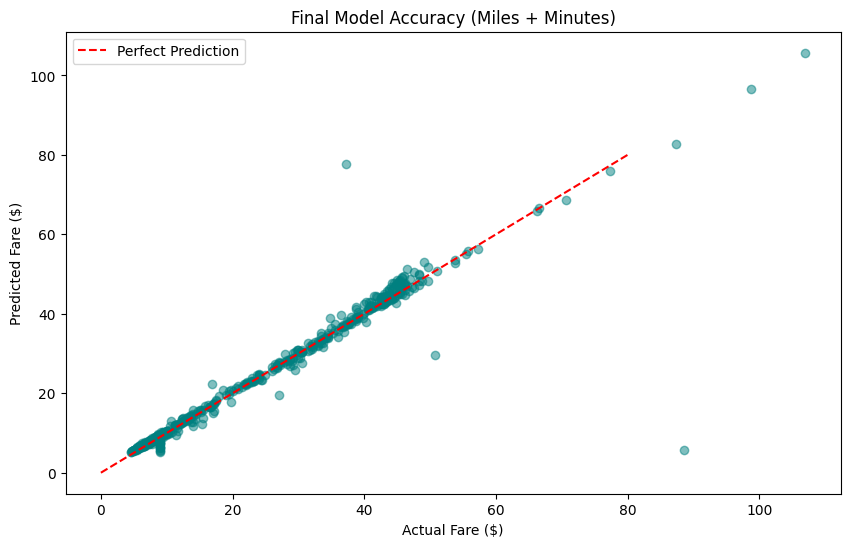

In [13]:
import matplotlib.pyplot as plt

# 1. Numeric Evaluation
sample_df = training_df.sample(500)
eval_results = model_2.evaluate(sample_df[['TRIP_MILES', 'TRIP_MINUTES']], sample_df['FARE'], verbose=0)
print(f"Evaluation RMSE: ${eval_results[1]:.2f}")

# 2. Visual Evaluation (Actual vs Predicted)
predictions = model_2.predict(sample_df[['TRIP_MILES', 'TRIP_MINUTES']])

plt.figure(figsize=(10, 6))
plt.scatter(sample_df['FARE'], predictions, alpha=0.5, color='teal')
plt.plot([0, 80], [0, 80], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.title('Final Model Accuracy (Miles + Minutes)')
plt.legend()
plt.show()

### 🔮 Inference

Inference is using the trained model to make predictions on new, real-world data where we don't know the answer.

In [14]:
import pandas as pd

# Predict fare for a new trip: 5 miles and 15 minutes
new_trip = pd.DataFrame({'TRIP_MILES': [5.0], 'TRIP_MINUTES': [15.0]})

predicted_fare = model_2.predict(new_trip)

print(f"Predicted fare for a 5-mile trip taking 15 minutes: ${predicted_fare[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted fare for a 5-mile trip taking 15 minutes: $16.22
